In [53]:
import pandas as pd
import numpy as np

In [54]:
df = pd.read_csv('last_data.csv')
print(df.head())

      Date xu100_closing bist100_closing housing_price_index exc_rate  \
0  Q1-1998       32,5906             NaN                 NaN  0,22346   
1  Q2-1998            41             NaN                 NaN  0,25259   
2  Q3-1998       22,6594             NaN                 NaN  0,27175   
3  Q4-1998       25,9791             NaN                 NaN  0,29297   
4  Q1-1999       45,5407             NaN                 NaN  0,34102   

  interest_rate cpi_rate reserves_total govt_balance unemployment loan_growth  \
0           NaN      NaN      28.498,70            0          NaN         NaN   
1           NaN      NaN      34.304,20            0          NaN         NaN   
2           NaN      NaN      35.329,10            0          NaN         NaN   
3           NaN      NaN      29.551,00            0          NaN         NaN   
4           NaN      NaN      30.808,40            0          NaN         NaN   

  growth_rate non_perf_loans non_perf_growth  
0         NaN            Na

In [55]:
# convert strings in data to floats

for i in range(1, len(df.columns)):
    df.iloc[:, i] = df.iloc[:, i].str.replace(".", "")
    df.iloc[:, i] = df.iloc[:, i].str.replace(",", ".").astype(float)

print(df.head())

      Date xu100_closing bist100_closing housing_price_index exc_rate  \
0  Q1-1998       32.5906             NaN                 NaN  0.22346   
1  Q2-1998          41.0             NaN                 NaN  0.25259   
2  Q3-1998       22.6594             NaN                 NaN  0.27175   
3  Q4-1998       25.9791             NaN                 NaN  0.29297   
4  Q1-1999       45.5407             NaN                 NaN  0.34102   

  interest_rate cpi_rate reserves_total govt_balance unemployment loan_growth  \
0           NaN      NaN        28498.7          0.0          NaN         NaN   
1           NaN      NaN        34304.2          0.0          NaN         NaN   
2           NaN      NaN        35329.1          0.0          NaN         NaN   
3           NaN      NaN        29551.0          0.0          NaN         NaN   
4           NaN      NaN        30808.4          0.0          NaN         NaN   

  growth_rate non_perf_loans non_perf_growth  
0         NaN            Na

In [87]:
# drop rows with NaN values at 'non_perf_growth' column
df = df.dropna(subset=['non_perf_growth'])
print(df.head())
print(df.shape)

       Date xu100_closing bist100_closing housing_price_index exc_rate  \
32  Q1-2006        429.23             NaN                 NaN  1.32568   
33  Q2-2006         354.4             NaN                 NaN  1.44947   
34  Q3-2006        370.83             NaN                 NaN  1.49453   
35  Q4-2006        392.26             NaN                 NaN  1.45041   
36  Q1-2007        436.56             NaN                 NaN  1.40426   

   interest_rate cpi_rate reserves_total govt_balance unemployment  \
32      18.21583   123.86        76719.9   -1759666.0     9.414125   
33      16.84231   127.56        79295.0    2893795.0     8.737319   
34      19.85462   129.89        84053.8   -4367715.0      8.91119   
35      20.22231   133.71        92336.3   -2534707.0     8.638185   
36      19.42769   136.64        99516.5   -3514963.0     8.828129   

   loan_growth growth_rate non_perf_loans non_perf_growth  
32    7.937549   -13.31138      7842232.0            0.02  
33     17.4972

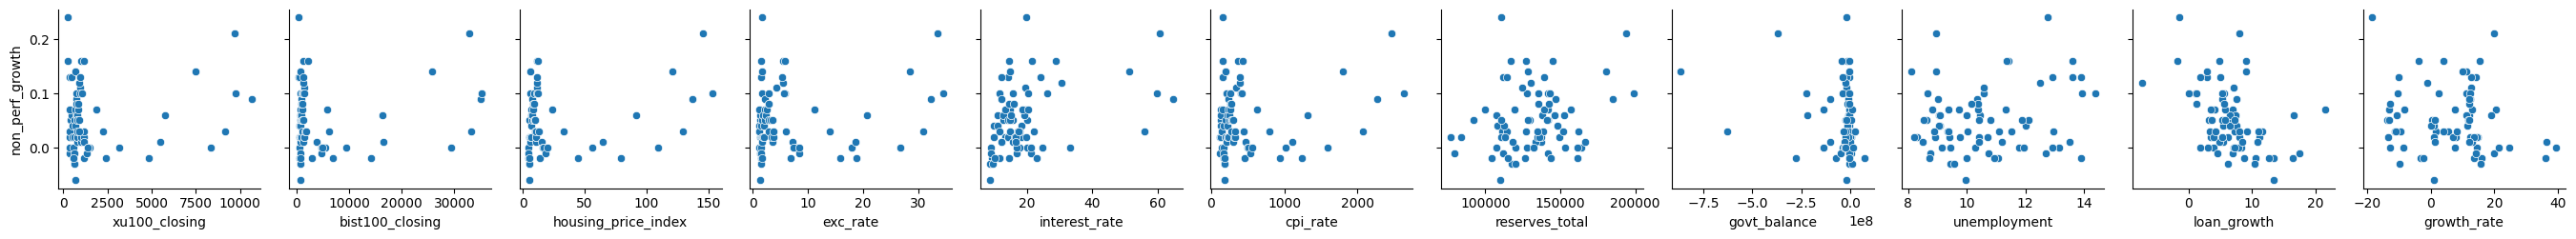

In [92]:
# plot non_perf_growth against all features as a pairs plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, x_vars=df.columns[1:-2], y_vars='non_perf_growth')
plt.show()

In [69]:
# test train split 
from sklearn.model_selection import train_test_split

X = df.drop(["Date", "non_perf_loans", "non_perf_growth"], axis=1)
Y = df["non_perf_growth"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=7)

In [83]:
# model fitting
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf_model_1 = RandomForestRegressor(n_estimators=100, random_state=7)

rf_model_1.fit(X_train, Y_train)

y_pred = rf_model_1.predict(X_test)

mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("Mean Squared Error: ", mse)
print("R2 Score: ", r2)

Mean Squared Error:  0.0027119137499999986
R2 Score:  0.31499761223483025


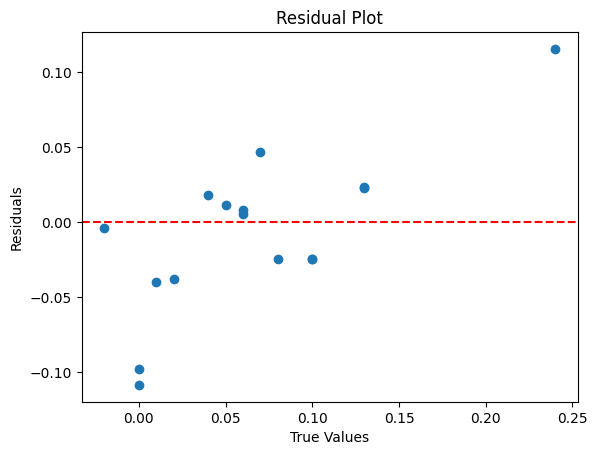

In [84]:
import matplotlib.pyplot as plt

residuals = Y_test - y_pred

plt.scatter(Y_test, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("True Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

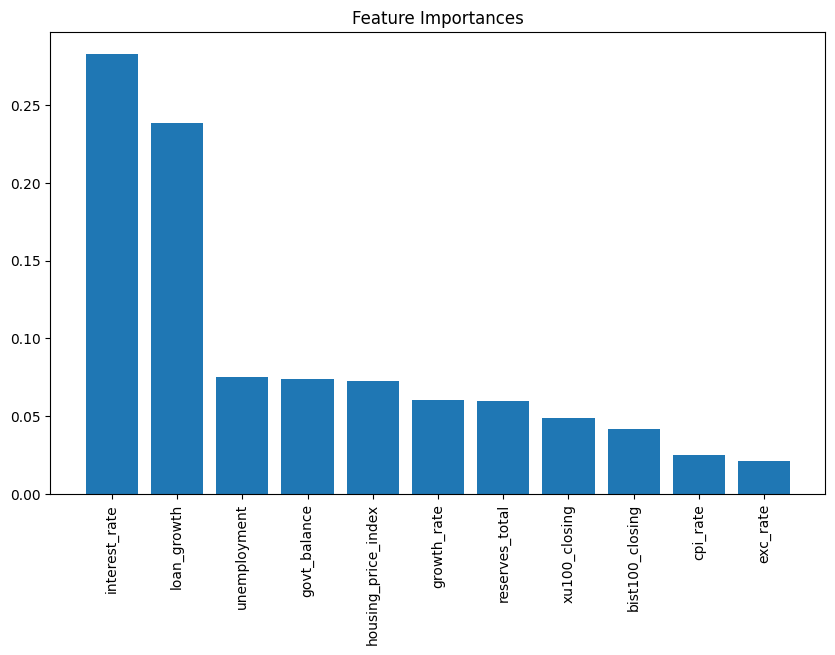

In [59]:
# feature importance
import matplotlib.pyplot as plt

feature_importance_1 = rf_model_1.feature_importances_
indices_1 = np.argsort(feature_importance_1)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), feature_importance_1[indices_1], align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices_1], rotation=90)
plt.show()

In [95]:
# grid search hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300, 1000],
    'max_depth': [None, 10, 20, 30],
}

# Initialize GridSearchCV
grid_search = GridSearchCV(RandomForestRegressor(random_state=190), param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, Y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=190),
             param_grid={'max_depth': [None, 10, 20, 30],
                         'n_estimators': [200, 300, 1000]},
             scoring='r2')

In [97]:
# make predictions
y_pred_2 = grid_search.predict(X_test)

best_model = grid_search.best_estimator_

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best OOB Score:", grid_search.best_score_)
print("Best MSE:", mean_squared_error(Y_test, grid_search.best_estimator_.predict(X_test)))
print("Best R² Score on Test Data:", r2_score(Y_test, y_pred_2))

Best Parameters: {'max_depth': None, 'n_estimators': 1000}
Best OOB Score: 0.19655436966727188
Best MSE: 0.002533212631250015
Best R² Score on Test Data: 0.3601357339911162


In [99]:
rf_model_gscv = RandomForestRegressor(n_estimators=1000, random_state=190)

rf_model_gscv.fit(X_train, Y_train)

y_pred_gscv = rf_model_gscv.predict(X_test)

mse = mean_squared_error(Y_test, y_pred_gscv)
r2 = r2_score(Y_test, y_pred_gscv)

print("Mean Squared Error: ", mse)
print("R2 Score: ", r2)

Mean Squared Error:  0.002533212631250015
R2 Score:  0.3601357339911162


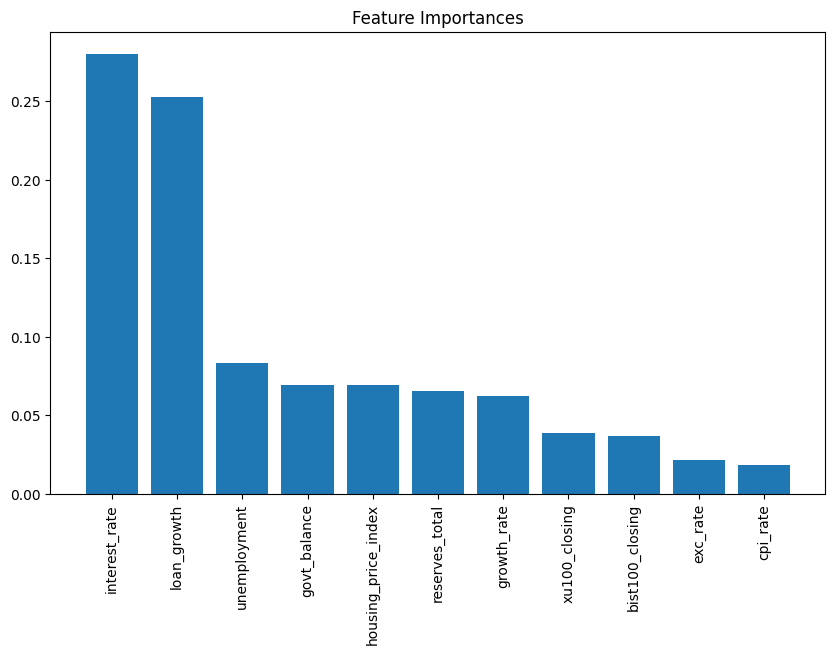

In [101]:
feature_importance_gscv = rf_model_gscv.feature_importances_
indices_gscv = np.argsort(feature_importance_gscv)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), feature_importance_gscv[indices_gscv], align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices_gscv], rotation=90)
plt.show()

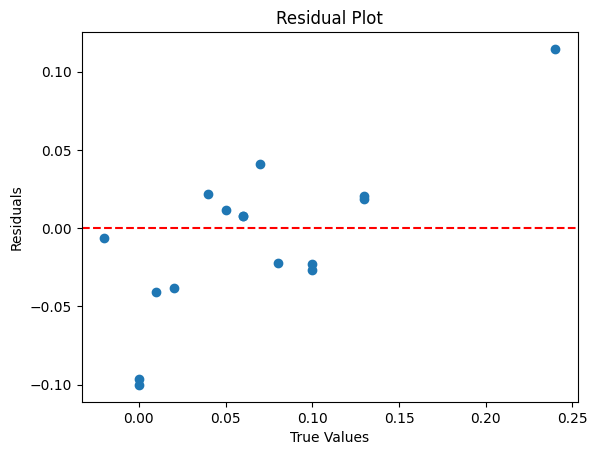

In [102]:
residuals = Y_test - y_pred_gscv

plt.scatter(Y_test, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("True Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [103]:
# LOOCV for the existing model
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

predictions = []
true_values = []

# Initialize model
rf_model = RandomForestRegressor(n_estimators=1000, random_state=190)

# Loop through each train-test split
for train_index, test_index in loo.split(X):
    X_train_loo, X_test_loo = X.iloc[train_index], X.iloc[test_index]
    Y_train_loo, Y_test_loo = Y.iloc[train_index], Y.iloc[test_index]
    
    # Train model
    rf_model.fit(X_train_loo, Y_train_loo)
    
    # Predict on the test sample
    pred = rf_model.predict(X_test_loo)
    
    # Store the prediction and true value
    predictions.append(pred[0])  # Convert array to scalar
    true_values.append(Y_test_loo.values[0])

mse = mean_squared_error(true_values, predictions)
r2 = r2_score(true_values, predictions)

print(f"Mean Squared Error (LOOCV): {mse}")
print(f"R² Score (LOOCV): {r2}")

Mean Squared Error (LOOCV): 0.0023844919881578926
R² Score (LOOCV): 0.2925984240251476


In [116]:
from sklearn.utils import resample

n_bootstraps = 1000
bootstrap_r2 = []
bootstrap_mse = []

for _ in range(n_bootstraps):
    X_train_bootstrap, Y_train_bootstrap = resample(X_train, Y_train, random_state=_)
    rf_model_gscv.fit(X_train_bootstrap, Y_train_bootstrap)
    y_pred_bootstrap = rf_model_gscv.predict(X_test)
    
    bootstrap_r2.append(r2_score(Y_test, y_pred_bootstrap))
    bootstrap_mse.append(mean_squared_error(Y_test, y_pred_bootstrap))

print(f"Bootstrap R²: {np.mean(bootstrap_r2):.4f} ± {np.std(bootstrap_r2):.4f}")
print(f"Bootstrap MSE: {np.mean(bootstrap_mse):.4f} ± {np.std(bootstrap_mse):.4f}")

Bootstrap R²: 0.2387 ± 0.1572
Bootstrap MSE: 0.0030 ± 0.0006


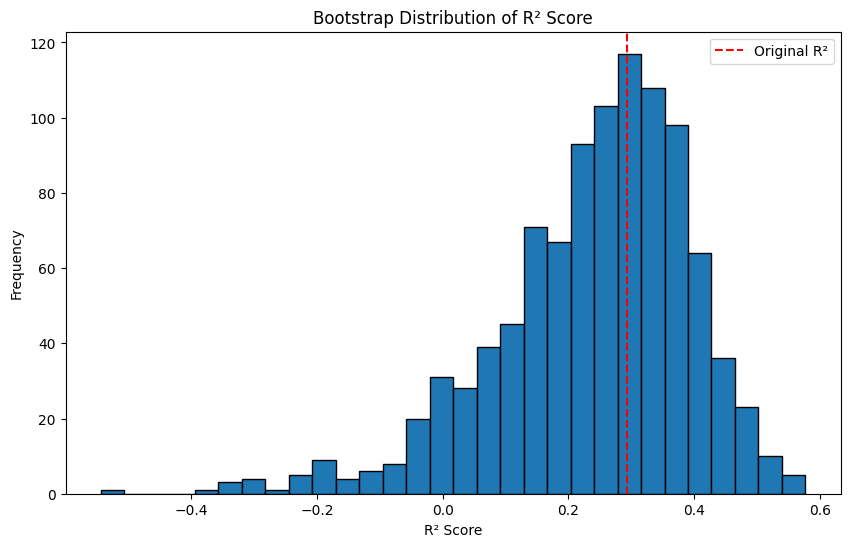

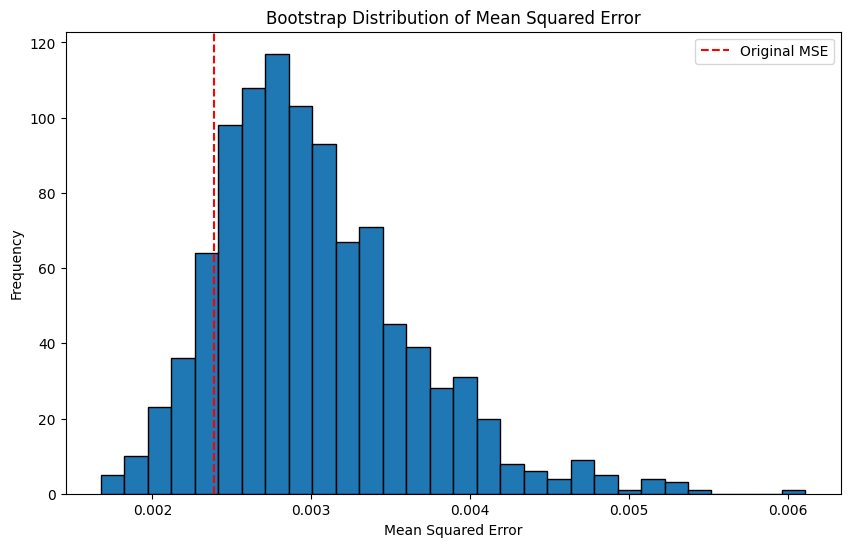

In [117]:
# plot the bootstrap distribution of r2 and mse
plt.figure(figsize=(10, 6))
plt.hist(bootstrap_r2, bins=30, edgecolor='black')
plt.axvline(r2, color='red', linestyle='--', label='Original R²')
plt.xlabel("R² Score")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of R² Score")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(bootstrap_mse, bins=30, edgecolor='black')
plt.axvline(mse, color='red', linestyle='--', label='Original MSE')
plt.xlabel("Mean Squared Error")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Mean Squared Error")
plt.legend()
plt.show()